# SupplyPrescript

# Sprint 6 - Machine Learning

## Objective

Build a machine learning model capable of predicting shipment disruptions.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

import joblib

In [2]:
df = pd.read_csv("../data/features/feature_dataset.csv")

df.head()

,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,...,Disruption_Occurred,Year,Month,Day,DayOfWeek,Cost_Per_KM,Risk_LeadTime,Weight_Per_KM,Risk_Reliability,High_Risk
0,7,4,1,4,5930.83,197.42,2.43,5.0,2,0.865,...,1,2025,10,16,4,0.000410,206.950,0.033287,0.6750,0
1,7,7,1,0,14285.36,237.24,2.30,7.5,4,0.592,...,1,2024,4,24,6,0.000161,306.900,0.016607,3.0600,1
2,5,4,1,2,11113.91,427.42,1.78,5.6,3,0.673,...,0,2024,1,26,0,0.000160,64.624,0.038458,1.8312,0
3,1,3,1,1,9180.55,170.66,3.20,0.8,2,0.832,...,1,2024,10,8,5,0.000349,42.504,0.018589,0.1344,0
4,1,8,0,2,2762.27,434.96,2.77,1.9,1,0.741,...,1,2024,9,7,2,0.001003,0.950,0.157465,0.4921,0


In [3]:
X = df.drop("Disruption_Occurred", axis=1)

y = df["Disruption_Occurred"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [5]:
model = XGBClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6
)

model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [6]:
y_pred = model.predict(X_test)

In [7]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.717


In [8]:
print("Precision:", precision_score(y_test, y_pred))

print("Recall:", recall_score(y_test, y_pred))

print("F1 Score:", f1_score(y_test, y_pred))

Precision: 0.7652733118971061
Recall: 0.7765089722675367
F1 Score: 0.7708502024291498


In [9]:
conf_matrix = confusion_matrix(y_test, y_pred)

print(conf_matrix)

[[241 146]
 [137 476]]


In [10]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.64      0.62      0.63       387
           1       0.77      0.78      0.77       613

    accuracy                           0.72      1000
   macro avg       0.70      0.70      0.70      1000
weighted avg       0.72      0.72      0.72      1000



In [11]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
8,Weather_Condition,0.321675
7,Geopolitical_Risk_Score,0.086278
10,Lead_Time_Days,0.083659
18,Risk_Reliability,0.044166
6,Fuel_Price_Index,0.034402
15,Cost_Per_KM,0.034294
16,Risk_LeadTime,0.034247
17,Weight_Per_KM,0.034027
2,Transport_Mode,0.033540
5,Weight_MT,0.033430


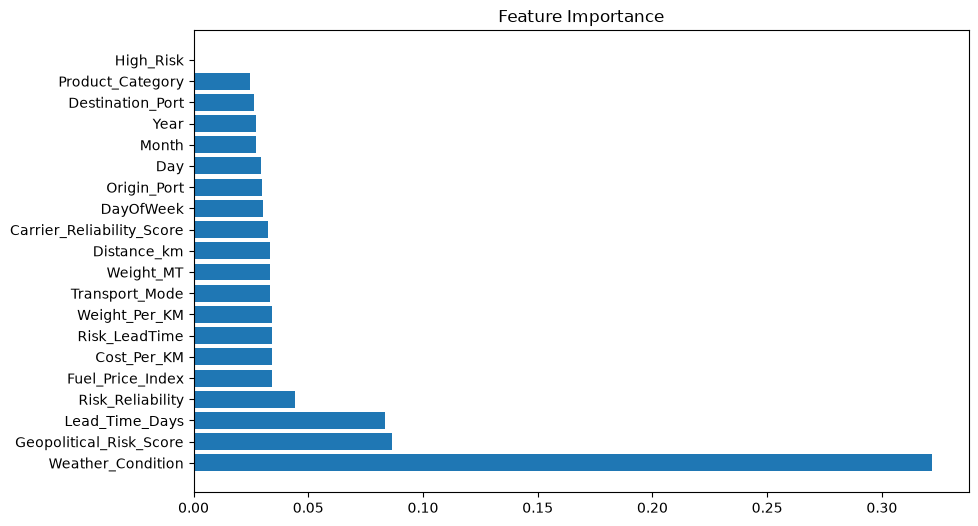

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.show()

In [13]:
import os

os.makedirs("../models", exist_ok=True)

In [14]:
joblib.dump(
    model,
    "../models/disruption_prediction_model.pkl"
)

['../models/disruption_prediction_model.pkl']

In [15]:
os.listdir("../models")

['disruption_prediction_model.pkl']

# Model Summary

Algorithm

XGBoost Classifier

Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1 Score

Output

Predicts whether a shipment is likely to experience disruption.